# Uczenie reprezentacji wielokanałowego EEG do klasyfikacji choroby Alzheimera

**Raport końcowy - projekt zespołowy (Uczenie Reprezentacji)**

| Osoba | Wkład |
|---|---|
| **Filip** | Potok danych (preprocessing, czyszczenie, cięcie EEG), infrastruktura repozytorium (DVC), baseline (Autoenkoder) |
| **Damian** | Definicja, adaptacja i trening dwóch modeli kontrastywnych (TNC, CPC) + klasyfikacja liniowa |
| **Jakub** | Model przestrzeni stanów Mamba, ewaluacja końcowa, badanie hiperparametrów struktur sieciowych |

---
# 1. Opis problemu

### 1.1. Dane wejściowe
Wielokanałowe sygnały **EEG** ze zbioru **BrainLat**. Surowe nagrania (EEGLAB `.set`) są cięte na **okna 3-sekundowe** i zapisywane jako tensory PyTorch - jeden plik na pacjenta, kształt `(liczba_okien, 128 kanałów, 1536 próbek)`. Okna zachowują **kolejność czasową**, co jest kluczowe dla metod kontrastywnych wykorzystujących strukturę czasu.

### 1.2. Dane wyjściowe
Binarna etykieta diagnozy: **AD** (Alzheimer, `1`) vs **CN** (grupa kontrolna, `0`). Zbiór: **67 pacjentów** (32 CN, 35 AD).

### 1.3. Typ problemu
**Klasyfikacja binarna.** Reprezentacje uczone są **bez etykiet** (samonadzorowanie); etykiety wchodzą dopiero na etapie *klasyfikacji liniowej* (linear evaluation).

### 1.4. Hipoteza badawcza
> Reprezentacje wyuczone metodami kontrastywnymi (TNC, CPC), wykorzystującymi **strukturę czasową** EEG, dadzą cechy lepiej rozdzielające klasy AD/CN niż naiwny baseline (Autoenkoder rekonstrukcyjny) - mierzone wyższym **ROC-AUC** w klasyfikacji liniowej.

### 1.5. Czym jest "klasyfikacja liniowa" (linear evaluation)
Standardowy protokół oceny reprezentacji w uczeniu samonadzorowanym:
1. enkoder uczy się **bez etykiet**;
2. enkoder jest **zamrażany** (wagi nie zmieniają się);
3. na zamrożonych cechach trenujemy **wyłącznie prosty klasyfikator** (liniowy / płytka głowica);
4. mierzymy AUC/accuracy.

Jeśli słaby klasyfikator liniowy potrafi rozdzielić klasy na danych cechach, to znaczy, że **enkoder nauczył się użytecznej, liniowo separowalnej reprezentacji**. Liniowość izoluje wkład samego enkodera.

---
# 2. Dane: wczytanie, preprocessing, przygotowanie
### *(sekcja Filipa - poniżej struktura do uzupełnienia)*

**Do opisania:**
- Źródło i charakterystyka zbioru BrainLat (liczba pacjentów, kanały, częstotliwość próbkowania, długość nagrań).
- Kroki preprocessingu: wczytanie (MNE), filtrowanie częstotliwościowe, usuwanie artefaktów, cięcie na okna 3 s, normalizacja.
- Format wyjściowy (`data/processed/*.pt`), mapowanie etykiet (AD=1, CN=0).
- Podział danych: `StratifiedGroupKFold` na poziomie pacjenta (brak data leakage).

In [1]:
# (Filip) miejsce na kod preprocessingu / wczytania surowych danych, jeśli ma być w raporcie.
# Przetworzone dane są już dostępne w data/processed/*.pt i wczytywane w sekcji 3.1 poniżej.

---
# 3. Baseline - Autoenkoder
### *(sekcja Filipa - kod i struktura przygotowane, do opisania słownie)*

**Do opisania:**
- **Krótki opis:** konwolucyjny Autoenkoder uczony rekonstrukcją (MSE); enkoder `Conv1d→BN→ReLU→MaxPool` ×2.
- **Odpalenie dla domyślnych wartości** + klasyfikacja liniowa (AUC/acc po foldach) - kod w 3.2.
- **Wyniki i wnioski** - punkt odniesienia (*naiwny baseline*) dla metod kontrastywnych z sekcji 4–5.

Funkcje pomocnicze i wczytanie danych (sekcja 3.1) są współdzielone z częścią Damiana - definiujemy je raz, niżej.

## 3.1. Konfiguracja, wczytanie danych i funkcje wspólne
*(współdzielone przez sekcje 3–5)*

In [ ]:
import os, sys, glob, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score

ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.models.cpc import CPCModel
from src.models.tnc import TNCModel
from src.models.baseline_ae import Autoencoder
from src.models.linear_classifier import LinearClassifier
from src.data.dataloaders import get_fold_sequence_dataloaders, get_fold_dataloaders
from src.evaluation.encoders import build_encoder
# Wspólna logika treningu SSL i klasyfikacji liniowej - to samo źródło, którego używają
# skrypty CLI src/training/train_cpc.py i train_tnc.py (jedno miejsce prawdy, brak duplikacji).
from src.training.ssl_training import train_ssl as _train_ssl, linear_probe as _linear_probe

DATA_DIR = os.path.join(ROOT, 'data', 'processed')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print('ROOT      :', ROOT)
print('Urządzenie:', DEVICE)
print('Pliki .pt :', len(glob.glob(os.path.join(DATA_DIR, '*.pt'))))

ROOT      : e:\Realny dysk\II_stopien\1_sem\Uczenie_Reprezentacji\Laby\Alzheimer-classifier
Urządzenie: cuda
Pliki .pt : 67


**Przełącznik trybu.** Trening na CPU jest wolny. `QUICK=True` → szybki przebieg do weryfikacji poprawności; `QUICK=False` → pełne wyniki do sprawozdania (najlepiej GPU).

**Zapisywanie / wczytywanie (dla współpracy i DVC).** Wytrenowane enkodery zapisują się do `models/representations/<wariant>/encoder_fold_*.pth` (→ DVC), a wyniki liczbowe (historie, tabele) do `notebooks/results/*.{json,csv}` (→ git). Gdy `LOAD_PRETRAINED=True` i pliki są na dysku (np. po `dvc pull` + `git pull`), notebook **wczytuje gotowe wyniki i NIE trenuje** - inna osoba odtwarza raport bez kosztownego treningu.

In [3]:
QUICK = True            # <-- False dla pełnego eksperymentu (najlepiej GPU)
LOAD_PRETRAINED = True   # <-- True: wczytuj gotowe wyniki/wagi jeśli są; False: zawsze trenuj od zera

if QUICK:
    N_SPLITS, SSL_EPOCHS, PROBE_EPOCHS = 2, 3, 10
    HP_SPLITS, SSL_EPOCHS_FINAL = 2, 3
else:
    # Wariant BEZ glowicy projekcyjnej (use_projection=False w modelach -- patrz ablacja w 4.1/5.1).
    # 5-fold CV dla wynikow finalnych. Badanie wplywu HP na HP_SPLITS=3 foldach (tansze, a wystarcza
    # do wyboru 2 najlepszych wartosci). Zamiast random search: mala siatka 2x2 z dwoch najlepszych
    # wartosci kazdego z dwoch HP, oceniana na pelnym 5-fold CV. best trenowany dluzej (SSL_EPOCHS_FINAL).
    N_SPLITS, SSL_EPOCHS, PROBE_EPOCHS = 5, 30, 30
    HP_SPLITS, SSL_EPOCHS_FINAL = 3, 40

RESULTS_DIR = os.path.join(ROOT, 'notebooks', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Tryb: {"SZYBKI" if QUICK else "PEŁNY (bez głowicy)"} | n_splits={N_SPLITS} hp_splits={HP_SPLITS} '
      f'ssl={SSL_EPOCHS} ssl_final={SSL_EPOCHS_FINAL} probe={PROBE_EPOCHS} | LOAD_PRETRAINED={LOAD_PRETRAINED}')

Tryb: SZYBKI | n_splits=2 hp_splits=2 ssl=3 ssl_final=3 probe=10 | LOAD_PRETRAINED=True


C:\Users\damia\AppData\Local\Temp\ipykernel_10700\952519505.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  n_per_patient = [torch.load(f).shape[0] for f in files]
C:\Us

Pacjentów: 67  (CN=32, AD=35)
Kształt pacjenta: (200, 128, 1536)  -> (okna, kanały, próbki)
Okien/pacjenta: min=47 max=225 śr=148
Fold 0: 33 train / 34 val pacjentów | leakage: 0 (musi być 0)


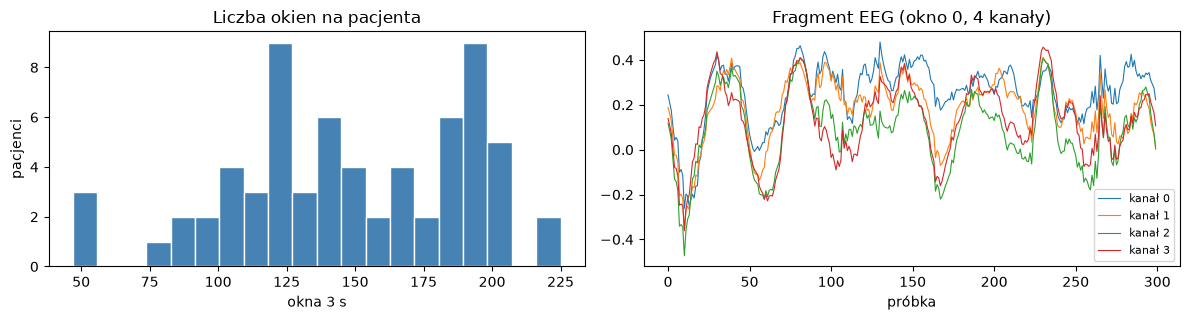

In [4]:
# --- Inspekcja danych: kształt, rozkład klas, brak przecieku pacjentów ---
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.pt')))
labels = [int(os.path.basename(f).split('_label_')[1].replace('.pt','')) for f in files]
n_per_patient = [torch.load(f).shape[0] for f in files]
ex = torch.load(files[0])

print(f'Pacjentów: {len(files)}  (CN={labels.count(0)}, AD={labels.count(1)})')
print(f'Kształt pacjenta: {tuple(ex.shape)}  -> (okna, kanały, próbki)')
print(f'Okien/pacjenta: min={min(n_per_patient)} max={max(n_per_patient)} śr={np.mean(n_per_patient):.0f}')

fold0, tl_seq, vl_seq = next(get_fold_sequence_dataloaders(DATA_DIR, n_splits=N_SPLITS))
leak = set(tl_seq.dataset.subjects) & set(vl_seq.dataset.subjects)
print(f'Fold 0: {len(tl_seq)} train / {len(vl_seq)} val pacjentów | leakage: {len(leak)} (musi być 0)')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
ax[0].hist(n_per_patient, bins=20, color='steelblue', edgecolor='white')
ax[0].set_title('Liczba okien na pacjenta'); ax[0].set_xlabel('okna 3 s'); ax[0].set_ylabel('pacjenci')
for ch in range(4):
    ax[1].plot(ex[0, ch, :300].numpy(), lw=0.8, label=f'kanał {ch}')
ax[1].set_title('Fragment EEG (okno 0, 4 kanały)'); ax[1].set_xlabel('próbka'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Metryki, walidacja i funkcje wspólne

**Metryki:** **ROC-AUC** (wiodąca) i **Accuracy**, średnia ± std po foldach. Dodatkowo per-pacjent: **F1, Precision, Recall** dla klasy AD (sekcja 7.1).

**Walidacja krzyżowa (cała próba, bez osobnego test setu).** `StratifiedGroupKFold` (**5 foldów**) na **poziomie pacjenta**: żaden pacjent nie jest jednocześnie w treningu i walidacji (brak *data leakage*). Wynik = średnia z 5 foldów.
> Przy 67 pacjentach **nie** wydzielamy osobnego zbioru testowego - held-out test miałby ~13 osób (loteria), a tracilibyśmy dane treningowe. CV na całej próbie to standard dla małych zbiorów.

**Dobór hiperparametrów - dwa etapy o różnym koszcie.**
- **Badanie wpływu HP** (4.3 / 5.3) liczymy na **3 foldach** (`HP_SPLITS`) - pokazuje *trend* i wyłania 2 najlepsze wartości każdego parametru.
- **Siatka 2×2** (4.4 / 5.4) - finalny dobór - sprawdza 4 kombinacje (2 najlepsze wartości × 2 najlepsze) na **pełnym 5-fold CV**. Zastępuje random search: deterministyczna, tania, oparta na danych z badania HP.

**Finalny model `best`** trenowany z większą liczbą epok SSL (`SSL_EPOCHS_FINAL=40` vs `SSL_EPOCHS=30`) - finalny wariant zasługuje na dłuższy trening.

**Uwaga o uczciwości.** Siatka 2×2 i wariant „best" korzystają z tego samego CV, na którym raportujemy wynik → lekkie optymistyczne obciążenie „best". Pełna ścisłość wymagałaby *nested CV* (niepraktycznego przy tak małym zbiorze). „best" = orientacyjny sufit, „domyślny" = uczciwy wynik bez strojenia.

**Ablacja głowicy projekcyjnej.** Cały ten przebieg jest **bez głowicy SimCLR** (`use_projection=False`) - wcześniejszy wariant z głowicą obniżał AUC na tym małym zbiorze (patrz 4.1/5.1).

**Funkcje pomocnicze:** `linear_probe()`, `train_ssl()`, `run_cv_smart()` (train-or-load), `eval_n_folds()` (ocena konfiguracji HP), `hp_study()` (3 foldy, trend) + `top2()`, `grid_search()` (siatka 2×2 na pełnym CV).

In [ ]:
# ---------- zapis / odczyt lekkich wyników (-> git) ----------
def _res(name): return os.path.join(RESULTS_DIR, name)
def save_json(o, name):
    with open(_res(name), 'w', encoding='utf-8') as f: json.dump(o, f)
def load_json(name):
    with open(_res(name), 'r', encoding='utf-8') as f: return json.load(f)
def save_df(df, name): df.to_csv(_res(name), index=False)
def load_df(name): return pd.read_csv(_res(name))
def results_exist(*names): return all(os.path.exists(_res(n)) for n in names)

# ---------- zapis / odczyt wag enkoderów (-> DVC) ----------
def _enc_path(variant, fold):
    return os.path.join(ROOT, 'models', 'representations', variant, f'encoder_fold_{fold}.pth')
def save_encoder(model, variant, fold):
    os.makedirs(os.path.dirname(_enc_path(variant, fold)), exist_ok=True)
    torch.save(model.encoder.state_dict(), _enc_path(variant, fold)); return _enc_path(variant, fold)
def all_encoders_exist(variant, n_splits):
    return all(os.path.exists(_enc_path(variant, f)) for f in range(n_splits))

# ---------- trening SSL i klasyfikacja liniowa ----------
# Rdzeń (pętla treningu, probe) jest w src/training/ssl_training.py - to SAMO źródło, którego
# używają skrypty CLI train_cpc.py / train_tnc.py. Tu tylko cienkie wrappery dokładające DEVICE.
def train_ssl(model, seq_loader, epochs, lr=1e-3, verbose=True):
    return _train_ssl(model, seq_loader, epochs, DEVICE, lr=lr, verbose=verbose)

def linear_probe(encoder, encoded_size, tl, vl, epochs, lr=5e-3):
    return _linear_probe(encoder, encoded_size, tl, vl, epochs, DEVICE, lr=lr)

# ---------- CV ----------
def run_cv(model_factory, ssl_epochs, n_splits, probe_epochs, lr_ssl=1e-3, verbose=True, save_variant=None):
    accs, aucs, hists = [], [], []
    seq_gen = get_fold_sequence_dataloaders(DATA_DIR, n_splits=n_splits)
    win_gen = get_fold_dataloaders(DATA_DIR, n_splits=n_splits, batch_size=64)
    for (fold, tl_seq, _), (_, tl_win, vl_win) in zip(seq_gen, win_gen):
        s, _ = next(iter(tl_seq)); C, T = s.shape[1], s.shape[2]
        if verbose: print(f'--- FOLD {fold} (trening) ---')
        m = model_factory(C, T)
        h = train_ssl(m, tl_seq, ssl_epochs, lr=lr_ssl, verbose=verbose)
        if save_variant: save_encoder(m, save_variant, fold)
        m.encoder.eval()
        acc, auc = linear_probe(m.encoder, m.encoded_size, tl_win, vl_win, probe_epochs)
        if verbose: print(f'  -> linear-eval: Acc {acc:.4f} | AUC {auc:.4f}')
        accs.append(acc); aucs.append(auc); hists.append(h)
    return accs, aucs, hists

def run_cv_pretrained(variant, model_name, n_splits, probe_epochs, verbose=True):
    """Wczytuje gotowe enkodery (bez treningu SSL), robi tylko klasyfikację liniową."""
    accs, aucs = [], []
    for fold, tl_win, vl_win in get_fold_dataloaders(DATA_DIR, n_splits=n_splits, batch_size=64):
        s, _ = next(iter(tl_win)); C, T = s.shape[1], s.shape[2]
        enc, es = build_encoder(model_name, C, T, DEVICE)
        enc.load_state_dict(torch.load(_enc_path(variant, fold), map_location=DEVICE)); enc.eval()
        if verbose: print(f'--- FOLD {fold} (wczytano {variant}/encoder_fold_{fold}.pth) ---')
        acc, auc = linear_probe(enc, es, tl_win, vl_win, probe_epochs)
        if verbose: print(f'  -> linear-eval: Acc {acc:.4f} | AUC {auc:.4f}')
        accs.append(acc); aucs.append(auc)
    return accs, aucs, []

def run_cv_smart(model_factory, model_name, variant, ssl_epochs, n_splits, probe_epochs,
                 lr_ssl=1e-3, hist_file=None, res_file=None):
    """Train-or-load: (1) są zapisane wyniki -> wczytaj; (2) są wagi -> wczytaj+linear-probe;
    (3) brak -> trenuj od zera i zapisz wagi+wyniki."""
    if LOAD_PRETRAINED and res_file and results_exist(res_file):
        r = load_json(res_file)
        hist = load_json(hist_file) if (hist_file and results_exist(hist_file)) else []
        print(f'[{variant.upper()}] Wczytano zapisane wyniki ({res_file}) - bez treningu.')
        return r['accs'], r['aucs'], hist
    if LOAD_PRETRAINED and all_encoders_exist(variant, n_splits):
        print(f'[{variant.upper()}] Wczytuję gotowe enkodery (wagi) - bez treningu SSL.')
        accs, aucs, hist = run_cv_pretrained(variant, model_name, n_splits, probe_epochs)
    else:
        if LOAD_PRETRAINED: print(f'[{variant.upper()}] Brak zapisanych wyników/wag -> trening od zera.')
        accs, aucs, hist = run_cv(model_factory, ssl_epochs, n_splits, probe_epochs, lr_ssl=lr_ssl, save_variant=variant)
    if res_file: save_json({'accs': accs, 'aucs': aucs}, res_file)
    if hist_file and hist: save_json(hist, hist_file)
    return accs, aucs, hist

# ---------- ocena konfiguracji HP (bez zapisu wag) ----------
# eval_n_folds: srednie AUC/Acc po `n_folds` foldach dla danej konfiguracji. n_folds=HP_SPLITS dla badania
# wplywu HP (tanio), n_folds=N_SPLITS dla siatki 2x2 (rzetelny wybor finalny na pelnym CV).
def eval_n_folds(model_factory, ssl_epochs, probe_epochs, n_folds, lr_ssl=1e-3):
    accs, aucs, _ = run_cv(model_factory, ssl_epochs, n_folds, probe_epochs,
                           lr_ssl=lr_ssl, verbose=False, save_variant=None)
    return float(np.mean(accs)), float(np.mean(aucs)), float(np.std(aucs))

_METRIC_COLS = ('Accuracy', 'ROC-AUC', 'ROC-AUC_std')

def hp_study(build_model, param_name, grid, fixed, res_file):
    """Badanie WPLYWU jednego hiperparametru na HP_SPLITS foldach (srednia +/- std).

    Pokazuje TREND (jak wartosc parametru wplywa na AUC) i sluzy do wyboru 2 najlepszych wartosci
    do siatki 2x2. HP_SPLITS (3) < N_SPLITS (5) -> tansze niz pelne CV, a wystarcza do rankingu wartosci."""
    if LOAD_PRETRAINED and results_exist(res_file):
        print(f'Wczytano zapisaną tabelę badania HP ({res_file}).'); return load_df(res_file)
    rows = []
    for val in grid:
        print(f'[{param_name} = {val}] ({HP_SPLITS}-fold CV...)')
        params = {**fixed, param_name: val}
        acc, auc, sd = eval_n_folds(lambda C, T, p=params: build_model(C, T, **p), SSL_EPOCHS, PROBE_EPOCHS, HP_SPLITS)
        rows.append({param_name: val, 'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4), 'ROC-AUC_std': round(sd, 4)})
        print(f'    -> AUC {auc:.4f} +/- {sd:.4f}')
    df = pd.DataFrame(rows); save_df(df, res_file); return df

def top2(hp_df, param_name):
    """Dwie wartosci parametru o najwyzszym ROC-AUC z tabeli badania HP (do siatki 2x2)."""
    best = hp_df.sort_values('ROC-AUC', ascending=False)[param_name].tolist()
    return best[:2]

def grid_search(build_model, grid_dict, res_file):
    """Pelna siatka kombinacji (tu 2x2 = 4 konfiguracje) oceniana na PELNYM N_SPLITS CV.
    Zastepuje random search: maly, deterministyczny przeglad najlepszych wartosci HP."""
    if LOAD_PRETRAINED and results_exist(res_file):
        print(f'Wczytano zapisaną tabelę siatki HP ({res_file}).'); return load_df(res_file)
    import itertools
    keys = list(grid_dict.keys()); rows = []
    for combo in itertools.product(*[grid_dict[k] for k in keys]):
        params = {k: (v.item() if hasattr(v, 'item') else v) for k, v in zip(keys, combo)}
        acc, auc, sd = eval_n_folds(lambda C, T, p=params: build_model(C, T, **p), SSL_EPOCHS, PROBE_EPOCHS, N_SPLITS)
        rows.append({**params, 'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4), 'ROC-AUC_std': round(sd, 4)})
        print(f'  {params} -> AUC {auc:.4f} +/- {sd:.4f}')
    df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    save_df(df, res_file); return df

def best_params_from(rs_df, int_keys):
    """Wyciąga najlepszy zestaw HP z tabeli siatki (bez kolumn metryk), rzutując wybrane na int."""
    p = {k: rs_df.iloc[0][k] for k in rs_df.columns if k not in _METRIC_COLS}
    for k in int_keys:
        if k in p: p[k] = int(p[k])
    return p

def fmt(vals): return f'{np.mean(vals):.3f} ± {np.std(vals):.3f}'
def plot_hist(hists, title, msg):
    if hists:
        plt.figure(figsize=(6, 3.3))
        for i, h in enumerate(hists): plt.plot(range(1, len(h)+1), h, marker='o', alpha=0.7, label=f'fold {i}')
        plt.title(title); plt.xlabel('epoka'); plt.ylabel('loss'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()
    else:
        print(msg)

## 3.2. Trening baseline'u (AE) + klasyfikacja liniowa

In [ ]:
def run_cv_ae(epochs, n_splits, probe_epochs, lr=1e-3, res_file='ae_default.json'):
    if LOAD_PRETRAINED and results_exist(res_file):
        r = load_json(res_file) 
        print(f'[AE] Wczytano zapisane wyniki ({res_file}).') 
        return r['accs'], r['aucs']
    accs, aucs = [], []
    for fold, tl, vl in get_fold_dataloaders(DATA_DIR, n_splits=n_splits, batch_size=64):
        s, _ = next(iter(tl))
        C, T = s.shape[1], s.shape[2]
        print(f'--- FOLD {fold} (AE) ---')

        ae = Autoencoder(C, T).to(DEVICE)
        crit = nn.MSELoss() 
        opt = optim.Adam(ae.parameters(), lr=lr)

        for ep in range(epochs):
            ae.train()
            for X, _ in tl:
                X = X.to(DEVICE); opt.zero_grad(); _, rec = ae(X)
                if rec.shape[2] != X.shape[2]: 
                    rec = nn.functional.interpolate(rec, size=X.shape[2])
                crit(rec, X).backward() 
                opt.step()
        save_encoder(ae, 'ae', fold) 
        ae.encoder.eval()
        acc, auc = linear_probe(ae.encoder, ae.encoded_size, tl, vl, probe_epochs)
        print(f'  -> linear-eval: Acc {acc:.4f} | AUC {auc:.4f}') 
        accs.append(acc); aucs.append(auc)
        
    save_json({'accs': accs, 'aucs': aucs}, res_file) 
    return accs, aucs

print('=== Baseline AE ===')
ae_acc, ae_auc = run_cv_ae(SSL_EPOCHS, N_SPLITS, PROBE_EPOCHS)
print(f'\nAE | Acc {fmt(ae_acc)} | AUC {fmt(ae_auc)}')

=== Baseline AE ===
[AE] Wczytano zapisane wyniki (ae_default.json).

AE | Acc 0.594 ± 0.087 | AUC 0.580 ± 0.111


---
# 4. TNC - Temporal Neighborhood Coding

## 4.1. Krótki opis
- **Publikacja:** Tonekaboni, Eytan, Goldenberg, *Unsupervised Representation Learning for Time Series with Temporal Neighborhood Coding*, ICLR 2021 (arXiv:2106.00750).
- **Idea:** dla okna kotwicznego `t` okna z **sąsiedztwa czasowego** są pozytywne, a odległe - negatywne. Dyskryminator uczy się je rozróżniać, co wymusza spójność reprezentacji w czasie. Oryginał stosuje **PU-learning**: odległe okna są *nieoznaczone* → strata negatywna ważona współczynnikiem `w`.
- **Nasze adaptacje / wprowadzone zmiany** (względem oryginału):
  1. enkoder splotowy 1D **wspólny dla TNC i CPC** (`src/models/encoder.py` - 4 bloki Conv1d 32→64→128→128 + GELU + global average pooling → reprezentacja **128-d**). Ten sam enkoder w obu metodach sprawia, że porównanie TNC vs CPC ocenia **samą metodę SSL**, a nie różnice architektury. (Oryginalne lab. TNC używa dwukierunkowego GRU - my adaptujemy do EEG, gdzie okno to wielokanałowy sygnał 128×1536, nie krótka sekwencja);
  2. sąsiedztwo = prosty promień `neighbor_range` (uproszczenie wobec gaussowskiego `t*~N(t, η·δ)` + testu ADF z oryginału);
  3. **ablacja głowicy projekcyjnej (SimCLR).** Sprawdziliśmy wariant z głowicą MLP 128→128→64 (strata na `g(z)`, ewaluacja na surowym 128-d). Na tym **małym zbiorze (53 pacjentów treningowych) głowica systematycznie obniżała AUC** - efekt znany: SimCLR pomaga przy dużych zbiorach z mocną augmentacją, nie w tym reżimie. **Finalnie głowicy nie używamy** (`use_projection=False`).
  
  Implementacja modelu: `src/models/tnc.py`.

**Hiperparametry:** `neighbor_range`, `num_samples`, `w`.

## 4.2. Odpalenie dla wartości domyślnych

In [7]:
print('=== TNC (domyślne: neighbor_range=3, num_samples=5, w=0.05) ===')
t0 = time.time()
tnc_acc, tnc_auc, tnc_hist = run_cv_smart(
    lambda C, T: TNCModel(C, T, neighbor_range=3, num_samples=5, w=0.05),
    model_name='tnc', variant='tnc', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='tnc_default_hist.json', res_file='tnc_default.json',
)
print(f'\nTNC (domyślny) | Acc {fmt(tnc_acc)} | AUC {fmt(tnc_auc)}  ({time.time()-t0:.0f}s)')

=== TNC (domyślne: neighbor_range=3, num_samples=5, w=0.05) ===
[TNC] Wczytano zapisane wyniki (tnc_default.json) — bez treningu.

TNC (domyślny) | Acc 0.569 ± 0.127 | AUC 0.599 ± 0.146  (0s)


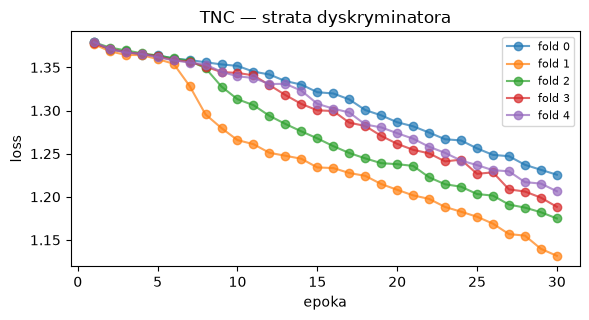

In [ ]:
plot_hist(tnc_hist, 'TNC - strata dyskryminatora',
          'Wczytano gotowe wyniki - brak historii treningu (ustaw LOAD_PRETRAINED=False, by ją zobaczyć).')

## 4.3. Badanie hiperparametrów

Dwa najważniejsze, specyficzne dla TNC hiperparametry badamy osobno (analogicznie do oryginalnego laboratorium TNC, gdzie badano `η`/sąsiedztwo oraz `w`). **Badanie wpływu liczymy na 3 foldach** (`HP_SPLITS`) - pokazuje *trend* i wyłania 2 najlepsze wartości każdego parametru do siatki 2×2 (sekcja 4.4).

> **Uwaga o `window_size`.** W oryginalnym laboratorium badano też `window_size`, ale u nas długość okna (3 s) jest **ustalona w preprocessingu** (`make_dataset`, sekcja Filipa) - okna są wycinane raz z surowego EEG, zanim model je zobaczy. Zmiana wymagałaby regeneracji całego zbioru, więc nie jest hiperparametrem modelu TNC i tu jej nie strojimy.

### 4.3a. Wpływ `neighbor_range`
Promień sąsiedztwa decyduje, jak "blisko" w czasie okna uznajemy za podobne (odpowiednik `η` z publikacji). Wynik zapisywany do `results/tnc_hp.csv`.

In [9]:
tnc_hp_df = hp_study(lambda C, T, **p: TNCModel(C, T, **p),
                     'neighbor_range', [1, 3, 5, 10], {'num_samples': 5, 'w': 0.05}, 'tnc_hp.csv')
tnc_hp_df

Wczytano zapisaną tabelę badania HP (tnc_hp.csv).


,neighbor_range,Accuracy,ROC-AUC,ROC-AUC_std
0,1,0.5612,0.5847,0.1002
1,3,0.6584,0.6827,0.0288
2,5,0.5383,0.5405,0.0447
3,10,0.6018,0.6068,0.1437


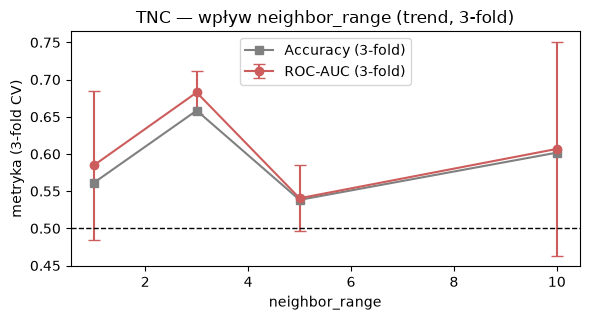

In [ ]:
plt.figure(figsize=(6, 3.3))
plt.errorbar(tnc_hp_df['neighbor_range'], tnc_hp_df['ROC-AUC'], yerr=tnc_hp_df['ROC-AUC_std'],
             marker='o', color='indianred', capsize=4, label='ROC-AUC (3-fold)')
plt.plot(tnc_hp_df['neighbor_range'], tnc_hp_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('TNC - wpływ neighbor_range (trend, 3-fold)'); plt.xlabel('neighbor_range'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

### 4.3b. Wpływ `w` (waga PU-learning)

Współczynnik `w` (Positive-Unlabeled learning) określa, w jakim stopniu okna **spoza** sąsiedztwa traktujemy jako potencjalnie pozytywne: strata negatywna to `w·BCE(·,1) + (1−w)·BCE(·,0)`. `w=0` → odległe okna są czysto negatywne; `w→1` → prawie pozytywne (model traci sygnał kontrastywny). Badamy wpływ na ROC-AUC (1 fold, trend). Wynik w `results/tnc_hp_w.csv`.

In [11]:
tnc_hp_w_df = hp_study(lambda C, T, **p: TNCModel(C, T, **p),
                       'w', [0.0, 0.05, 0.1, 0.2], {'neighbor_range': 3, 'num_samples': 5}, 'tnc_hp_w.csv')
tnc_hp_w_df

Wczytano zapisaną tabelę badania HP (tnc_hp_w.csv).


,w,Accuracy,ROC-AUC,ROC-AUC_std
0,0.00,0.5392,0.4994,0.1012
1,0.05,0.5676,0.5566,0.0383
2,0.10,0.5023,0.4783,0.0711
3,0.20,0.5256,0.5301,0.1322


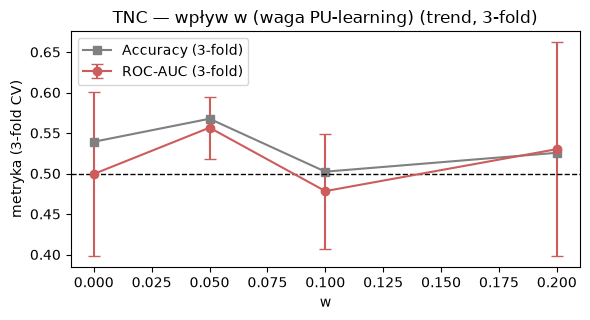

In [ ]:
plt.figure(figsize=(6, 3.3))
plt.errorbar(tnc_hp_w_df['w'], tnc_hp_w_df['ROC-AUC'], yerr=tnc_hp_w_df['ROC-AUC_std'],
             marker='o', color='indianred', capsize=4, label='ROC-AUC (3-fold)')
plt.plot(tnc_hp_w_df['w'], tnc_hp_w_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('TNC - wpływ w (waga PU-learning) (trend, 3-fold)'); plt.xlabel('w'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

## 4.4. Dobór hiperparametrów - siatka 2×2

Zamiast kosztownego random search bierzemy **2 najlepsze wartości** `neighbor_range` i **2 najlepsze** `w` z badania wpływu (4.3) i sprawdzamy wszystkie **4 kombinacje** na **pełnym 5-fold CV**. Najlepszy zestaw → wariant `tnc_best`. To deterministyczne, tanie (4 konfiguracje) i opiera wybór na danych z badania HP. Wynik w `results/tnc_rs.csv`.

In [13]:
# 2 najlepsze wartosci kazdego HP z badania wplywu (4.3a neighbor_range, 4.3b w) -> siatka 2x2
tnc_grid = {'neighbor_range': top2(tnc_hp_df, 'neighbor_range'),
            'w':             top2(tnc_hp_w_df, 'w'),
            'num_samples':   [5]}   # num_samples ustalone (mniej wplywowe); siatka 2x2 po nr x w
print('=== TNC siatka 2x2 ===  neighbor_range:', tnc_grid['neighbor_range'], '| w:', tnc_grid['w'])
tnc_rs = grid_search(lambda C, T, **p: TNCModel(C, T, **p), tnc_grid, 'tnc_rs.csv')
tnc_rs

=== TNC siatka 2x2 ===  neighbor_range: [3, 10] | w: [0.05, 0.2]
Wczytano zapisaną tabelę siatki HP (tnc_rs.csv).


,neighbor_range,w,num_samples,Accuracy,ROC-AUC,ROC-AUC_std
0,10,0.05,5,0.6610,0.7190,0.1159
1,10,0.20,5,0.5885,0.6280,0.1055
2,3,0.20,5,0.5295,0.5167,0.0645
3,3,0.05,5,0.5213,0.5006,0.1439


### TNC z najlepszymi hiperparametrami - pełne CV
Najlepszy zestaw z siatki 2×2 dotrenowujemy na **pełnym 5-fold CV**, z **większą liczbą epok SSL** (`SSL_EPOCHS_FINAL`) - finalny model zasługuje na dłuższy trening. Wariant `tnc_best` trafia do tabeli porównawczej (sekcja 7).

In [14]:
tnc_best_params = best_params_from(tnc_rs, int_keys=('neighbor_range', 'num_samples'))
print('Najlepsze HP TNC:', tnc_best_params, f'| epoki SSL = {SSL_EPOCHS_FINAL}')
t0 = time.time()
tnc_best_acc, tnc_best_auc, tnc_best_hist = run_cv_smart(
    lambda C, T: TNCModel(C, T, **tnc_best_params),
    model_name='tnc', variant='tnc_best', ssl_epochs=SSL_EPOCHS_FINAL, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='tnc_best_hist.json', res_file='tnc_best.json',
)
print(f'\nTNC (najlepszy) | Acc {fmt(tnc_best_acc)} | AUC {fmt(tnc_best_auc)}  ({time.time()-t0:.0f}s)')

Najlepsze HP TNC: {'neighbor_range': 10, 'w': 0.05, 'num_samples': 5} | epoki SSL = 3
[TNC_BEST] Wczytano zapisane wyniki (tnc_best.json) — bez treningu.

TNC (najlepszy) | Acc 0.658 ± 0.108 | AUC 0.676 ± 0.121  (0s)


## 4.5. Wyniki i wnioski - TNC
*(do uzupełnienia liczbami po `QUICK=False`)*
- Domyślny TNC vs baseline AE (sekcja 7): czy reprezentacja sąsiedztwa czasowego daje przewagę?
- `neighbor_range`: która wartość maksymalizuje AUC i dlaczego?
- Zysk z optymalizacji: najlepszy zestaw z random search względem domyślnego.

---
# 5. CPC - Contrastive Predictive Coding

## 5.1. Krótki opis
- **Publikacja:** van den Oord, Li, Vinyals, *Representation Learning with Contrastive Predictive Coding*, arXiv:1807.03748 (2018).
- **Idea:** enkoder `g_enc` koduje okno do `z_t`; autoregresor `g_ar` (**GRU**) buduje kontekst `c_t`. Dla horyzontu `k` projekcja `W_k` przewiduje `z_{t+k}`. Trening stratą **InfoNCE**.
- **Nasze adaptacje / wprowadzone zmiany:**
  1. enkoder splotowy **wspólny z TNC** (`src/models/encoder.py`, 128-d, global pooling) - patrz uwaga w 4.1;
  2. negatywy losowane wewnątrz sekwencji jednego pacjenta (in-batch negatives);
  3. **ablacja głowicy projekcyjnej (SimCLR)** - jak w TNC (4.1): sprawdzona, na tym zbiorze pogarsza wynik, więc finalnie `use_projection=False`.
  
  Implementacja modelu: `src/models/cpc.py`.

**Hiperparametry:** `prediction_steps`, `context_dim`.

## 5.2. Odpalenie dla wartości domyślnych

In [15]:
print('=== CPC (domyślne: context_dim=128, prediction_steps=4) ===')
t0 = time.time()
cpc_acc, cpc_auc, cpc_hist = run_cv_smart(
    lambda C, T: CPCModel(C, T, context_dim=128, prediction_steps=4),
    model_name='cpc', variant='cpc', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='cpc_default_hist.json', res_file='cpc_default.json',
)
print(f'\nCPC (domyślny) | Acc {fmt(cpc_acc)} | AUC {fmt(cpc_auc)}  ({time.time()-t0:.0f}s)')

=== CPC (domyślne: context_dim=128, prediction_steps=4) ===
[CPC] Wczytano zapisane wyniki (cpc_default.json) — bez treningu.

CPC (domyślny) | Acc 0.629 ± 0.093 | AUC 0.632 ± 0.145  (0s)


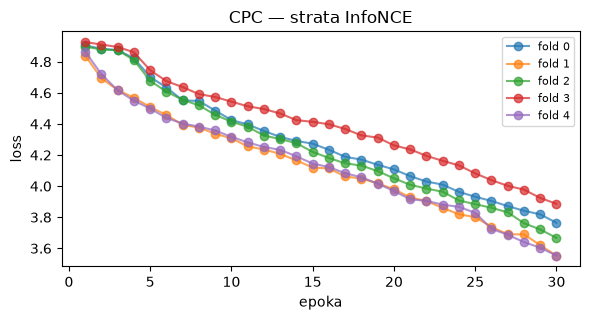

In [ ]:
plot_hist(cpc_hist, 'CPC - strata InfoNCE',
          'Wczytano gotowe wyniki - brak historii treningu (ustaw LOAD_PRETRAINED=False, by ją zobaczyć).')

## 5.3. Badanie hiperparametrów

Dwa hiperparametry CPC badamy osobno na **3 foldach** (`HP_SPLITS`) - pokazuje trend i wyłania 2 najlepsze wartości każdego do siatki 2×2 (5.4).

### 5.3a. Wpływ `prediction_steps`
Liczba kroków predykcji w przód. Większa wartość = dłuższe zależności czasowe, ale trudniejsze zadanie. Wynik w `results/cpc_hp.csv`.

In [17]:
cpc_hp_df = hp_study(lambda C, T, **p: CPCModel(C, T, **p),
                     'prediction_steps', [1, 2, 4, 8], {'context_dim': 128}, 'cpc_hp.csv')
cpc_hp_df

Wczytano zapisaną tabelę badania HP (cpc_hp.csv).


,prediction_steps,Accuracy,ROC-AUC,ROC-AUC_std
0,1,0.6486,0.6580,0.0525
1,2,0.5924,0.5936,0.1172
2,4,0.5582,0.5923,0.0550
3,8,0.6160,0.6566,0.0862


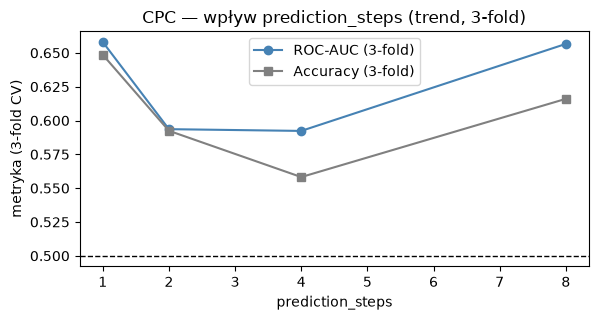

In [ ]:
plt.figure(figsize=(6, 3.3))
plt.plot(cpc_hp_df['prediction_steps'], cpc_hp_df['ROC-AUC'], marker='o', color='steelblue', label='ROC-AUC (3-fold)')
plt.plot(cpc_hp_df['prediction_steps'], cpc_hp_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('CPC - wpływ prediction_steps (trend, 3-fold)'); plt.xlabel('prediction_steps'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

### 5.3b. Wpływ `context_dim`

Wymiar kontekstu autoregresora GRU (`c_t`). Większy = pojemniejszy kontekst, ale więcej parametrów i ryzyko przeuczenia na małym zbiorze. Badamy wpływ na ROC-AUC (3 foldy, trend). Wynik w `results/cpc_hp_ctx.csv`.

In [19]:
cpc_hp_ctx_df = hp_study(lambda C, T, **p: CPCModel(C, T, **p),
                         'context_dim', [32, 64, 128, 256], {'prediction_steps': 4}, 'cpc_hp_ctx.csv')
cpc_hp_ctx_df

Wczytano zapisaną tabelę badania HP (cpc_hp_ctx.csv).


,context_dim,Accuracy,ROC-AUC,ROC-AUC_std
0,32,0.6072,0.6122,0.1068
1,64,0.5551,0.5335,0.0409
2,128,0.6265,0.6604,0.0503
3,256,0.5702,0.6102,0.0443


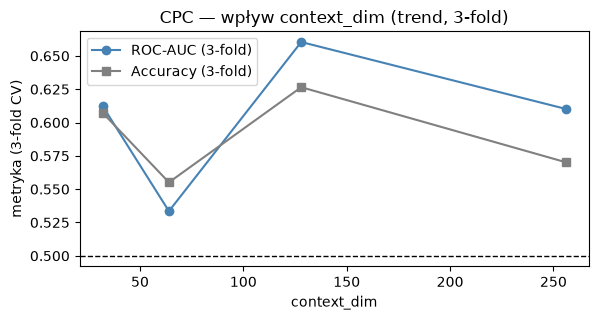

In [ ]:
plt.figure(figsize=(6, 3.3))
plt.plot(cpc_hp_ctx_df['context_dim'], cpc_hp_ctx_df['ROC-AUC'], marker='o', color='steelblue', label='ROC-AUC (3-fold)')
plt.plot(cpc_hp_ctx_df['context_dim'], cpc_hp_ctx_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('CPC - wpływ context_dim (trend, 3-fold)'); plt.xlabel('context_dim'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

## 5.4. Dobór hiperparametrów - siatka 2×2

2 najlepsze `prediction_steps` (5.3a) × 2 najlepsze `context_dim` (5.3b), wszystkie **4 kombinacje** na **pełnym 5-fold CV**. Najlepszy → `cpc_best`. Wynik w `results/cpc_rs.csv`.

In [21]:
# 2 najlepsze wartosci kazdego HP z badania wplywu (5.3a prediction_steps, 5.3b context_dim) -> siatka 2x2
cpc_grid = {'prediction_steps': top2(cpc_hp_df, 'prediction_steps'),
            'context_dim':      top2(cpc_hp_ctx_df, 'context_dim')}
print('=== CPC siatka 2x2 ===  prediction_steps:', cpc_grid['prediction_steps'], '| context_dim:', cpc_grid['context_dim'])
cpc_rs = grid_search(lambda C, T, **p: CPCModel(C, T, **p), cpc_grid, 'cpc_rs.csv')
cpc_rs

=== CPC siatka 2x2 ===  prediction_steps: [1, 8] | context_dim: [128, 32]
Wczytano zapisaną tabelę siatki HP (cpc_rs.csv).


,prediction_steps,context_dim,Accuracy,ROC-AUC,ROC-AUC_std
0,1,128,0.6854,0.7124,0.1074
1,1,32,0.6631,0.6719,0.1244
2,8,32,0.6007,0.6366,0.1836
3,8,128,0.6051,0.6241,0.0712


### CPC z najlepszymi hiperparametrami - pełne CV
Najlepszy zestaw z siatki 2×2 dotrenowany na **pełnym 5-fold CV**, z większą liczbą epok SSL (`SSL_EPOCHS_FINAL`). Wariant `cpc_best`.

In [22]:
cpc_best_params = best_params_from(cpc_rs, int_keys=('prediction_steps', 'context_dim'))
print('Najlepsze HP CPC:', cpc_best_params, f'| epoki SSL = {SSL_EPOCHS_FINAL}')
t0 = time.time()
cpc_best_acc, cpc_best_auc, cpc_best_hist = run_cv_smart(
    lambda C, T: CPCModel(C, T, **cpc_best_params),
    model_name='cpc', variant='cpc_best', ssl_epochs=SSL_EPOCHS_FINAL, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    hist_file='cpc_best_hist.json', res_file='cpc_best.json',
)
print(f'\nCPC (najlepszy) | Acc {fmt(cpc_best_acc)} | AUC {fmt(cpc_best_auc)}  ({time.time()-t0:.0f}s)')

Najlepsze HP CPC: {'prediction_steps': 1, 'context_dim': 128} | epoki SSL = 3
[CPC_BEST] Wczytano zapisane wyniki (cpc_best.json) — bez treningu.

CPC (najlepszy) | Acc 0.621 ± 0.084 | AUC 0.662 ± 0.107  (0s)


## 5.5. Wyniki i wnioski - CPC
*(do uzupełnienia liczbami po `QUICK=False`)*
- Domyślny CPC vs baseline AE: czy predykcja przyszłości daje lepsze cechy?
- `prediction_steps`: optymalny horyzont.
- Zysk z optymalizacji względem domyślnego.

---
# 6. Mamba - model przestrzeni stanów

---
# 7. Podsumowanie zbiorcze

Tabela i wykres zestawiające metody w wariancie **domyślnym i najlepszym** (po optymalizacji hiperparametrów). Wymagana przez specyfikację tabela głównego eksperymentu z porównaniem do naiwnego baseline'u.

In [ ]:
summary = pd.DataFrame([
    {'Model': 'Baseline (AE)', 'Acc (domyślny)': fmt(ae_acc), 'AUC (domyślny)': fmt(ae_auc),
     'Acc (najlepszy)': '-', 'AUC (najlepszy)': '-', '_auc': np.mean(ae_auc)},
    {'Model': 'TNC', 'Acc (domyślny)': fmt(tnc_acc), 'AUC (domyślny)': fmt(tnc_auc),
     'Acc (najlepszy)': fmt(tnc_best_acc), 'AUC (najlepszy)': fmt(tnc_best_auc), '_auc': np.mean(tnc_best_auc)},
    {'Model': 'CPC', 'Acc (domyślny)': fmt(cpc_acc), 'AUC (domyślny)': fmt(cpc_auc),
     'Acc (najlepszy)': fmt(cpc_best_acc), 'AUC (najlepszy)': fmt(cpc_best_auc), '_auc': np.mean(cpc_best_auc)},
]).sort_values('_auc', ascending=False).drop(columns='_auc').reset_index(drop=True)
print('Tabela główna - klasyfikacja liniowa, AUC/Acc (średnia ± std po CV):')
print('("najlepszy" = po optymalizacji hiperparametrów random searchem)')
summary

Tabela główna — klasyfikacja liniowa, AUC/Acc (średnia ± std po CV):
("najlepszy" = po optymalizacji hiperparametrów random searchem)


,Model,Acc (domyślny),AUC (domyślny),Acc (najlepszy),AUC (najlepszy)
0,TNC,0.569 ± 0.127,0.599 ± 0.146,0.658 ± 0.108,0.676 ± 0.121
1,CPC,0.629 ± 0.093,0.632 ± 0.145,0.621 ± 0.084,0.662 ± 0.107
2,Baseline (AE),0.594 ± 0.087,0.580 ± 0.111,—,—


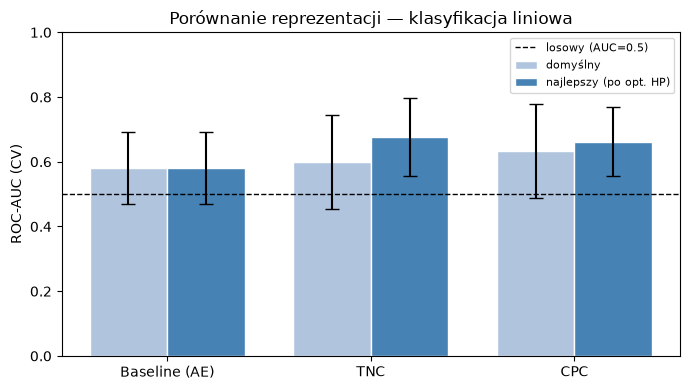

In [ ]:
names    = ['Baseline (AE)', 'TNC', 'CPC']
auc_def  = [np.mean(ae_auc), np.mean(tnc_auc), np.mean(cpc_auc)]
std_def  = [np.std(ae_auc),  np.std(tnc_auc),  np.std(cpc_auc)]
auc_best = [np.mean(ae_auc), np.mean(tnc_best_auc), np.mean(cpc_best_auc)]
std_best = [np.std(ae_auc),  np.std(tnc_best_auc),  np.std(cpc_best_auc)]
x = np.arange(len(names)); w = 0.38
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, auc_def,  w, yerr=std_def,  capsize=5, label='domyślny', color='lightsteelblue', edgecolor='white')
plt.bar(x + w/2, auc_best, w, yerr=std_best, capsize=5, label='najlepszy (po opt. HP)', color='steelblue', edgecolor='white')
plt.axhline(0.5, ls='--', c='k', lw=1, label='losowy (AUC=0.5)')
plt.xticks(x, names); plt.ylabel('ROC-AUC (CV)'); plt.ylim(0, 1)
plt.title('Porównanie reprezentacji - klasyfikacja liniowa'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7.1. Ewaluacja per-pacjent (agregacja okien)

Dotąd AUC liczyliśmy **per okno**. Ale diagnoza dotyczy **pacjenta**, a jeden pacjent ma 47–225 okien (które **nie są** niezależnymi próbkami). Bardziej poprawna metodologicznie i klinicznie ocena: agregujemy predykcje okien danego pacjenta (**średnie prawdopodobieństwo**) do jednej predykcji na pacjenta, a AUC liczymy na poziomie pacjentów.

Reużywamy **zapisane enkodery** każdego wariantu (bez ponownego treningu SSL) - dotrenowujemy tylko tanią głowicę liniową i porównujemy obie metryki obok siebie.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

def eval_per_patient(variant, model_name, probe_epochs=PROBE_EPOCHS, res_file=None):
    """Dla zapisanego enkodera danego wariantu: dotrenuj glowice liniowa na oknach i policz
    AUC/Acc per-okno ORAZ per-pacjent (srednie prawdopodobienstwo okien -> 1 predykcja/pacjent).
    Dodatkowo per-pacjent: F1, Precision, Recall (czulosc) -- istotne przy diagnozie medycznej,
    gdzie zalezy nam na wykryciu chorych (klasa AD=1), nie tylko ogolnej trafnosci.
    Reuzywa wag z dysku (bez treningu SSL). Zwraca dict list per-fold; cache w res_file."""
    if LOAD_PRETRAINED and res_file and results_exist(res_file):
        print(f'[{variant}] Wczytano zapisany per-patient ({res_file}).'); return load_json(res_file)
    win_auc, win_acc, pat_auc, pat_acc = [], [], [], []
    pat_f1, pat_prec, pat_rec = [], [], []
    seq_gen = get_fold_sequence_dataloaders(DATA_DIR, n_splits=N_SPLITS)
    win_gen = get_fold_dataloaders(DATA_DIR, n_splits=N_SPLITS, batch_size=64)
    for (fold, _, vl_seq), (_, tl_win, vl_win) in zip(seq_gen, win_gen):
        s, _ = next(iter(tl_win)); C, T = s.shape[1], s.shape[2]
        enc, es = build_encoder(model_name, C, T, DEVICE)
        enc.load_state_dict(torch.load(_enc_path(variant, fold), map_location=DEVICE)); enc.eval()
        # dotrenuj sama glowice (enkoder zamrozony w LinearClassifier)
        clf = LinearClassifier(enc, es).to(DEVICE)
        crit = nn.BCEWithLogitsLoss(); opt = optim.Adam(clf.classifier.parameters(), lr=5e-3)
        for _ in range(probe_epochs):
            clf.train()
            for X, y in tl_win:
                X = X.to(DEVICE); y = y.float().to(DEVICE).unsqueeze(1)
                opt.zero_grad(); crit(clf(X), y).backward(); opt.step()
        clf.eval()
        # per-okno
        P, Tt = [], []
        with torch.no_grad():
            for X, y in vl_win:
                P.extend(torch.sigmoid(clf(X.to(DEVICE))).cpu().numpy()); Tt.extend(y.numpy())
        P = np.array(P).ravel(); Tt = np.array(Tt).ravel()
        win_acc.append(accuracy_score(Tt, (P > 0.5))); win_auc.append(roc_auc_score(Tt, P))
        # per-pacjent: srednie prawdopodobienstwo okien danego pacjenta
        pp, pl = [], []
        with torch.no_grad():
            for seq, label in vl_seq:
                pr = torch.sigmoid(clf(seq.to(DEVICE))).cpu().numpy().ravel()
                pp.append(float(pr.mean())); pl.append(int(label))
        pred = [int(x > 0.5) for x in pp]
        pat_acc.append(accuracy_score(pl, pred)); pat_auc.append(roc_auc_score(pl, pp))
        # F1/Precision/Recall dla klasy AD=1 (zero_division=0: bezpieczne, gdy fold bez predykcji danej klasy)
        pat_f1.append(f1_score(pl, pred, zero_division=0))
        pat_prec.append(precision_score(pl, pred, zero_division=0))
        pat_rec.append(recall_score(pl, pred, zero_division=0))
    out = {'win_auc': win_auc, 'win_acc': win_acc, 'pat_auc': pat_auc, 'pat_acc': pat_acc,
           'pat_f1': pat_f1, 'pat_prec': pat_prec, 'pat_rec': pat_rec}
    if res_file: save_json(out, res_file)
    return out

_PP_VARIANTS = [('Baseline (AE)', 'ae', 'ae'),
                ('TNC',          'tnc', 'tnc'),
                ('TNC best',     'tnc_best', 'tnc'),
                ('CPC',          'cpc', 'cpc'),
                ('CPC best',     'cpc_best', 'cpc')]

pp_rows = []
for name, variant, model in _PP_VARIANTS:
    print(f'=== per-patient: {name} ===')
    r = eval_per_patient(variant, model, res_file=f'perpat_{variant}.json')
    pp_rows.append({'Model': name,
                    'AUC per-okno': fmt(r['win_auc']),
                    'AUC per-pacjent': fmt(r['pat_auc']),
                    'Acc per-pacjent': fmt(r['pat_acc']),
                    'F1 (AD)': fmt(r['pat_f1']),
                    'Precision (AD)': fmt(r['pat_prec']),
                    'Recall/czułość (AD)': fmt(r['pat_rec']),
                    '_pat': np.mean(r['pat_auc'])})
perpat_df = pd.DataFrame(pp_rows).sort_values('_pat', ascending=False).drop(columns='_pat').reset_index(drop=True)
print('\nTabela per-pacjent (średnia ± std po CV). F1/Precision/Recall dla klasy AD=1:')
print('(Recall = czułość: jaki odsetek chorych AD wykryto - kluczowe w diagnozie.)')
perpat_df

=== per-patient: Baseline (AE) ===
[ae] Wczytano zapisany per-patient (perpat_ae.json).
=== per-patient: TNC ===
[tnc] Wczytano zapisany per-patient (perpat_tnc.json).
=== per-patient: TNC best ===
[tnc_best] Wczytano zapisany per-patient (perpat_tnc_best.json).
=== per-patient: CPC ===
[cpc] Wczytano zapisany per-patient (perpat_cpc.json).
=== per-patient: CPC best ===
[cpc_best] Wczytano zapisany per-patient (perpat_cpc_best.json).

Tabela per-pacjent (średnia ± std po CV). F1/Precision/Recall dla klasy AD=1:
(Recall = czułość: jaki odsetek chorych AD wykryto — kluczowe w diagnozie.)


,Model,AUC per-okno,AUC per-pacjent,Acc per-pacjent,F1 (AD),Precision (AD),Recall/czułość (AD)
0,TNC best,0.620 ± 0.157,0.630 ± 0.177,0.581 ± 0.188,0.589 ± 0.168,0.627 ± 0.187,0.571 ± 0.181
1,CPC best,0.613 ± 0.140,0.582 ± 0.155,0.582 ± 0.139,0.554 ± 0.160,0.620 ± 0.154,0.514 ± 0.194
2,CPC,0.549 ± 0.156,0.549 ± 0.165,0.553 ± 0.123,0.589 ± 0.132,0.559 ± 0.113,0.629 ± 0.171
3,TNC,0.557 ± 0.150,0.529 ± 0.193,0.584 ± 0.129,0.614 ± 0.138,0.591 ± 0.116,0.657 ± 0.194
4,Baseline (AE),0.525 ± 0.049,0.459 ± 0.147,0.523 ± 0.052,0.407 ± 0.332,0.333 ± 0.275,0.543 ± 0.455
